<a href="https://colab.research.google.com/github/Subhranshu-123/BIKE2/blob/main/Copy_of_NETWORK_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import networkx as nx

In [ ]:
import pandas as pd
import networkx as nx

# Load directly from a URL or local compressed file
url = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
df = pd.read_csv(url, sep=" ", names=["start_node", "end_node"])

# Create the graph from the dataframe
G = nx.from_pandas_edgelist(df, source="start_node", target="end_node")
print(df)


       start_node  end_node
0               0         1
1               0         2
2               0         3
3               0         4
4               0         5
...           ...       ...
88229        4026      4030
88230        4027      4031
88231        4027      4032
88232        4027      4038
88233        4031      4038

[88234 rows x 2 columns]


In [ ]:
import networkx as nx



# Calculate Centrality
degree_cent = nx.degree_centrality(G)
top_nodes = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:3]
print(f"Top 3 Influencers: {top_nodes}")

# Detect Communities
communities = nx.community.louvain_communities(G)
print(f"Found {len(communities)} social circles.")


Top 3 Influencers: [(107, 0.258791480931154), (1684, 0.1961367013372957), (1912, 0.18697374938088163)]
Found 16 social circles.


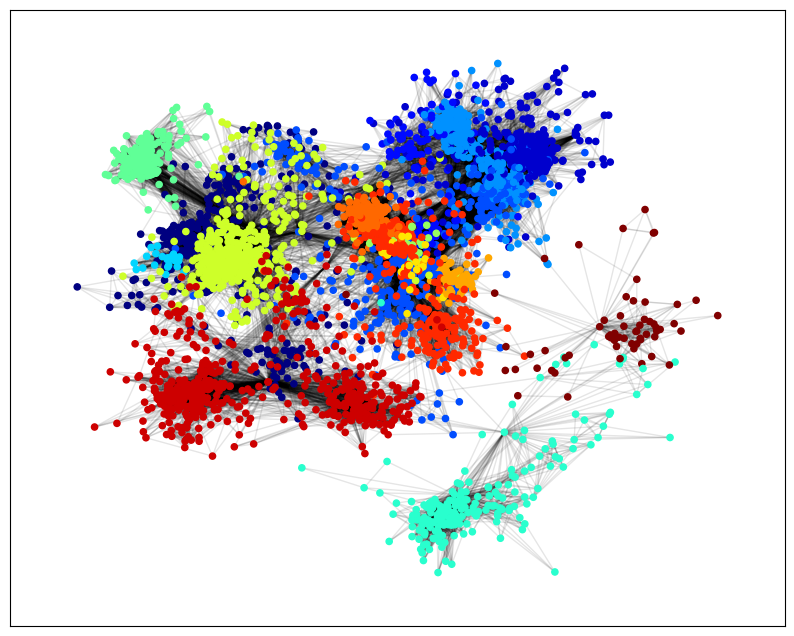

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Compute positions and communities
pos = nx.spring_layout(G, k=0.15, seed=42) # k adjusts node spacing
partition = nx.community.louvain_communities(G)

# Convert community list to a color mapping for each node
color_map = []
for node in G.nodes():
    for i, comm in enumerate(partition):
        if node in comm:
            color_map.append(i)
            break

# Draw the network
plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(G, pos, node_size=20, node_color=color_map, cmap=plt.cm.jet)
nx.draw_networkx_edges(G, pos, alpha=0.1) # low alpha helps handle dense edges
plt.show()


K-Core Decomposition (Finding the Dense Nucleus)

In [ ]:
# 1. Calculate centrality for all nodes
centrality = nx.degree_centrality(G)

# 2. Get the top 100 most influential nodes
top_nodes = sorted(centrality, key=centrality.get, reverse=True)[:100]
print(f"Top 100 Influencers: {top_nodes}")

# 3. Create a subgraph with just these nodes and their connections
G_filtered = G.subgraph(top_nodes)


Top 100 Influencers: [107, 1684, 1912, 3437, 0, 2543, 2347, 1888, 1800, 1663, 1352, 2266, 483, 348, 1730, 1985, 1941, 2233, 2142, 1431, 1199, 1584, 2206, 1768, 2229, 2410, 2611, 1086, 1589, 2047, 2218, 2078, 1993, 2123, 1746, 2464, 1827, 2240, 2507, 2560, 2244, 1983, 2309, 1126, 2088, 2131, 2340, 2602, 2324, 2369, 2590, 2542, 2604, 1804, 2073, 2220, 2607, 2188, 1390, 2059, 2172, 1943, 2150, 1833, 1946, 2428, 2526, 1377, 1612, 1917, 2201, 2331, 2601, 1621, 1938, 2090, 2384, 2118, 2564, 2624, 1714, 1962, 2030, 2586, 1559, 2064, 2184, 2625, 1707, 2275, 2593, 2615, 2111, 2103, 2290, 1078, 2323, 2414, 1376, 1613]


 Edge Weight Thresholding (Strengthening Connections)

In [ ]:
 # Create a copy and remove edges with weights below a threshold (e.g., 0.5)
threshold = 0.5
G_strong = G.copy()
weak_edges = [(u, v) for u, v, d in G_strong.edges(data=True) if d.get('weight', 1) < threshold]
G_strong.remove_edges_from(weak_edges)
print(f"Number of edges after edge weight thresholding: {G_strong.number_of_edges()}")


Number of edges after edge weight thresholding: 88234


In [ ]:
import networkx as nx
import urllib.request
import gzip
import shutil
import os

# 1. Download and Load Data
url = "https://snap.stanford.edu/data/facebook_combined.txt.gz"
file_name = "facebook_combined.txt.gz"

if not os.path.exists(file_name):
    print("Downloading dataset from SNAP...")
    urllib.request.urlretrieve(url, file_name)

# Load as an undirected graph
print("Loading graph...")
with gzip.open(file_name, 'rb') as f:
    G = nx.read_edgelist(f, nodetype=int)

# 2. Filter: K-Core Decomposition
# Keeps only nodes with at least 20 neighbors in the remaining subgraph
print("Applying K-Core filtering (k=20)...")
G_filtered = nx.k_core(G, k=20)

# 3. Calculate Attributes for Gephi
print("Calculating centrality measures...")
# Degree: Number of direct connections
degree_dict = dict(G_filtered.degree())
nx.set_node_attributes(G_filtered, degree_dict, 'degree')

# Betweenness: Importance as a 'bridge'
betweenness = nx.betweenness_centrality(G_filtered)
nx.set_node_attributes(G_filtered, betweenness, 'betweenness')

# Community: Group ID using Louvain method
communities = nx.community.louvain_communities(G_filtered)
community_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_map[node] = i
nx.set_node_attributes(G_filtered, community_map, 'modularity_class')

# 4. Export to Gephi
output_file = "facebook_filtered.gexf"
nx.write_gexf(G_filtered, output_file)
print(f"Success! Filtered graph saved as {output_file}")


Loading graph...
Applying K-Core filtering (k=20)...
Calculating centrality measures...
Success! Filtered graph saved as facebook_filtered.gexf


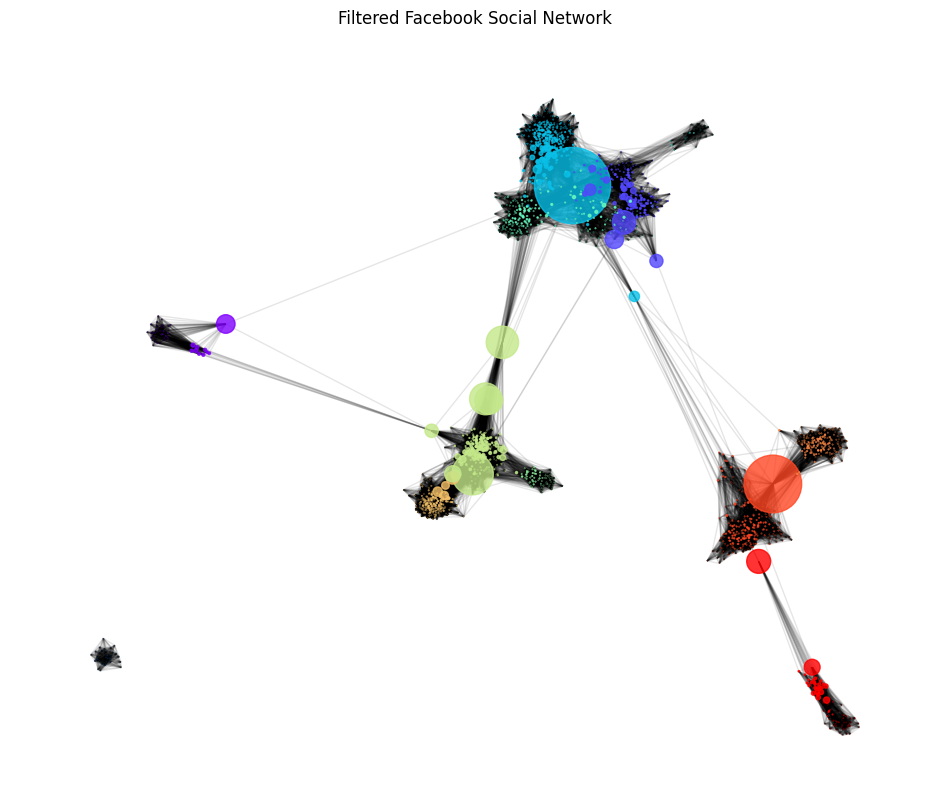

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Load the filtered graph
G = nx.read_gexf("/content/facebook_filtered.gexf")

# 2. Set up the visual layout
# spring_layout pulls connected nodes together into visible clusters
pos = nx.spring_layout(G, seed=42, k=0.15)

# 3. Extract node attributes for styling
# Use 'modularity_class' for colors and 'betweenness' for size (if you added them)
node_colors = [G.nodes[n].get('modularity_class', 0) for n in G.nodes()]
node_sizes = [G.nodes[n].get('betweenness', 0.01) * 5000 for n in G.nodes()]

# 4. Draw the graph
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, cmap=plt.cm.rainbow, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.1) # Set alpha low to see through the "hairball"

plt.title("Filtered Facebook Social Network")
plt.axis('off') # Hide axes for a cleaner look
plt.show()


In [ ]:
import networkx as nx
import pandas as pd

# Wiki-Vote Example
wiki_url = "https://snap.stanford.edu/data/wiki-Vote.txt.gz"
df_wiki = pd.read_csv(wiki_url, sep="\t", skiprows=4, names=['FromNodeId', 'ToNodeId'])
G_wiki = nx.from_pandas_edgelist(df_wiki, source='FromNodeId', target='ToNodeId', create_using=nx.DiGraph())

# Twitter Example (Combined Edge List)
twitter_url = "https://snap.stanford.edu/data/twitter_combined.txt.gz"
df_twitter = pd.read_csv(twitter_url, sep=" ", names=['FromNodeId', 'ToNodeId'])
G_twitter = nx.from_pandas_edgelist(df_twitter, source='FromNodeId', target='ToNodeId', create_using=nx.DiGraph())
print(df_wiki)
print(df_twitter)

        FromNodeId  ToNodeId
0               30      1412
1               30      3352
2               30      5254
3               30      5543
4               30      7478
...            ...       ...
103684        8272      4940
103685        8273      4940
103686        8150      8275
103687        8150      8276
103688        8274      8275

[103689 rows x 2 columns]
         FromNodeId   ToNodeId
0         214328887   34428380
1          17116707   28465635
2         380580781   18996905
3         221036078  153460275
4         107830991   17868918
...             ...        ...
2420761    99841247  154263215
2420762    99841247  194403468
2420763    99841247  180165101
2420764    99841247  253509115
2420765    99841247  463410501

[2420766 rows x 2 columns]
